In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp


import rover as rover_class
import grid_world
from astar_plan import AStarPlanner

import mpc_EKF
import mpc
# from mpc import *
np.random.seed(4)

In [2]:
# set-up orbit epoch, number of satellites, number of planes, and number of satellites per plane
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")
N_sat = 6
N_planes = 2
N_sat_plane = N_sat // N_planes
# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, 180])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([120, 240, 0])  # [rad] Mean anomaly

# group the together and create the initial state vectors
coe_mi = np.zeros((N_sat, 6))
rv0_moon_sat_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )
        rv0_moon_sat_mi[i_sat] = pnt.classical_to_cartesian(coe_mi[i_sat], pnt.MU_MOON)

# Time discretization
# TODO: this is where we can change things up depending on the simulation scenario
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 6 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 6 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
# NOTE: 3 days of simulation time takes 2 minutes and 36 seconds of computation time with the current time step
N_days = 1  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt) + 1  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body with Earth, no Sun included)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
# dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.CoordConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MI, pnt.PA
    )


Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


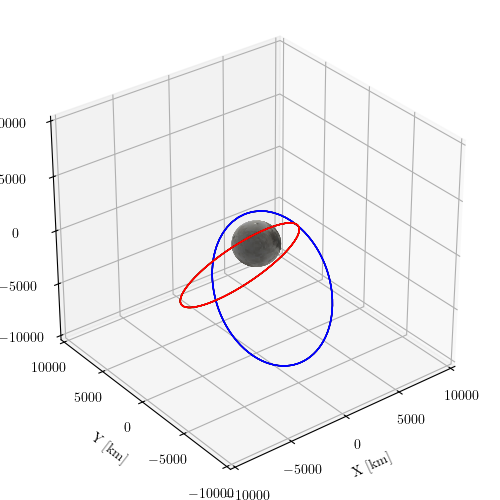

In [105]:
fig = pnt.plots.Plot3D(figsize=(5, 5), elev=31, azim=-128)
fig.plot_surface(pnt.MOON, scale=3)

# e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
# e_moon_earth = rv_moon_earth_mi[0, 0:3] / np.linalg.norm(rv_moon_earth_mi[0, 0:3])
orbit_color = np.array(["magenta", "green", "blue", "orange", "black", "red"])

for i_sat in range(N_sat):
    plt.plot(
        rv_moon_sat_mi[i_sat, :, 0],
        rv_moon_sat_mi[i_sat, :, 1],
        rv_moon_sat_mi[i_sat, :, 2],
        color=orbit_color[i_sat],
        linewidth=1,
    )
plt.tight_layout()
plt.savefig("figures/sats.png", dpi=600)

In [4]:
def get_pseudorange_measurement(satpos, x_est, use_Gnoise):
    # simulate pseudorange measurements from a given satellite
    # likely inputs: true satellite state, true receiver state
    # we can already add noise to the measurements here, or outside like in the MATLAB simulator
    # the pseudorange error model is the same as what we had from the endurance work
    # also let's get the Jacobian here too (maybe JAX can come in handy!)
    
    # x_est is a 1x3 np array and satpos is a Nx3 np array
    n_meas = satpos.shape[0]
    los = np.tile(x_est, (n_meas, 1)) - satpos # Nx3
    range = np.linalg.norm(los, axis=1) # 1xN
    # Added simple Gaussian noise model
    if use_Gnoise:
        Gnoise = np.random.normal(0.0, 1.0, size=n_meas)
        range += Gnoise
    # print('los = ', los)
    # print('range = ', range)
    e = los / np.tile(range, (3, 1)).T # Nx3
    H = e
    return range, H

def get_pseudorange_rate_measurement():
    # simulate pseudorange rate measurements from a given satellite
    # now the error model for this... is a little different and we need to think about it more
    # plus we need this for the ION paper too
    raise NotImplementedError

def get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi, fcar=2492.028e6, LNA_NF_dB = 1, rec_Tsys_K = 113):
    # assume that the satellite is always pointing towards the center of the moon
    # we are going to need some antenna gain patterns for this, but we can fish them out from the MATLAB simulator
    # simulate the carrier-to-noise ratio for a given satellite
    c = 299792458
    k_dBW_K_Hz = -228.6
    FSPL_dB = 20*np.log10(4*np.pi*dist_m*fcar/c)
    Prx = EIRP_beta_dBW - FSPL_dB
    Teq_K = rec_Tsys_K + 290*(10**(LNA_NF_dB/10)-1)
    Teq_dB = 10*np.log10(Teq_K)
    g_over_T = rec_gain_theta_dBi - Teq_dB
    cn0_dBHz = Prx + g_over_T - k_dBW_K_Hz
    # cn0 = 10**(cn0_dBHz/10) # Hz
    return cn0_dBHz

def mcmf_to_enu(lat_user, lon_user):
    # convert from MCMF to ENU coordinates
    # lat_user = rover latitude in radians (1x1)
    # lon_user = rover longitude in radians (1x1)
    phi, lmda = lat_user, lon_user
    M = np.array([
        [-np.sin(lmda), np.cos(lmda), 0],
        [-np.cos(lmda)*np.sin(phi), -np.sin(lmda)*np.sin(phi), np.cos(phi)],
        [np.cos(lmda)*np.cos(phi), np.sin(lmda)*np.cos(phi), np.sin(phi)]
    ])
    return M
    
def get_elev_azim(M, mcmf_sat, user_mcmf_rv):
    # get the elevation and azimuth of a given satellite (VALIDATED WITH PATHFINDER ORBIT)
    # M = output of mcmf_to_enu function (6x6)
    # mcmf_sat = Nx6 state vector of satellite (N is number of satellites)
    # user_mcmf_rv = 1x6 state vector of rover

    # note that mcmf_sat is a N_sat X N_time X x 6 array
    lent = mcmf_sat.shape[1]
    enu_sat = np.zeros(mcmf_sat.shape)
    el_sat, az_sat = np.zeros((mcmf_sat.shape[0], lent)), np.zeros((mcmf_sat.shape[0], lent))

    for sat_idx in range(mcmf_sat.shape[0]):
        for t in range(mcmf_sat.shape[1]):  
            enu_sat[sat_idx, t, :] = block_diag(M, M) @ (mcmf_sat[sat_idx,t,:] - user_mcmf_rv)
            norm_enu_sat = np.linalg.norm(enu_sat[sat_idx, t, :3])

            el_sat[sat_idx,t] = np.degrees(np.arcsin(enu_sat[sat_idx, t, 2] / norm_enu_sat))  # up

            norm_east, norm_north = enu_sat[sat_idx, t, 0] / norm_enu_sat, enu_sat[sat_idx, t, 1] / norm_enu_sat
            az_sat_rad = np.mod(np.arctan2(norm_east, norm_north), 2 * np.pi)
            az_sat[sat_idx, t] = np.degrees(az_sat_rad)

    return el_sat, az_sat


In [5]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)

# # assume the user is at the Poincare crater (in rad)
# lat_user = np.deg2rad(-90)
# lon_user = np.deg2rad(0)

# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

N_t = len(tspan)          # number of time steps
resolution = 0.1            # resolution of the grid 100 m x 100 m

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(40, resolution, N_t, rover.rover_loc, 0.0, 0.02)
# let's add some craters (if you do not specify location, they will be randomly placed)
# Set the grid
crater = grid_env.create_crater(20, 1, (15, 18))
grid_env.add_crater(crater, slope_factor=0.6)

crater = grid_env.create_crater(15, 2, (35, 30))
grid_env.add_crater(crater, slope_factor=0.3)

crater = grid_env.create_crater(4, 1.5, (18, 15))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(12, 2, (-4, 11))
grid_env.add_crater(crater, slope_factor=0.8)

crater = grid_env.create_crater(8, 1, (10, 20))
grid_env.add_crater(crater, slope_factor=0.4)

crater = grid_env.create_crater(10, 2.2, (15, 40))
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(6, 1.2, (30, 15))
grid_env.add_crater(crater, slope_factor=0.5)


# crater = grid_env.create_crater(10, 2.5, [20, 20])
# grid_env.add_crater(crater, slope_factor=0.5)

In [6]:
grid_coords, grid_lat_long= grid_env.grid_PA_coords(lat_user, lon_user)

# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
N_grid = grid_env.grid.shape[0]

EIRP_beta_dBW = 14
rec_gain_theta_dBi = 3

visible_sat_num = np.zeros((N_sat, len(tspan)))

elev_mask = 10

for i in range(N_grid):
    for j in range(N_grid):
        cell_lat, cell_lon = grid_lat_long[i, j, :]
        cell_pos_pa = grid_coords[i, j, :]
        M = mcmf_to_enu(cell_lat, cell_lon)
        user_pa = np.array([cell_pos_pa[0], cell_pos_pa[1], cell_pos_pa[2], 0, 0, 0])
        el_sat, az_sat = get_elev_azim(M, rv_moon_sat_pa, user_pa)
        t_PDOP = np.zeros(N_t)
        for t in range(N_t):
            visible_satpos = np.zeros((N_sat, 3))
            # Save the satellite position only if the satellite is visible
            for i_sat in range(N_sat):
                dist_m = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3] - user_pa[:3]) * 1000 # only this is in meters
                cn0 = get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi) # dBHz
                # if elevation is greater than 10 and cn0 > 30 dBHz, then the satellite is considered visible
                if (el_sat[i_sat, t] > elev_mask) and (cn0 > 30): 
                    visible_satpos[i_sat] = rv_moon_sat_pa[i_sat, t, :3]
                    visible_sat_num[i_sat] = el_sat[i_sat] > elev_mask
                elif cn0 <= 30:
                    print('Signal is not strong enough.')
            # Remove the zero rows (i.e., the rows corresponding to the satellites that are not visible)
            non_zero_rows = ~np.all(visible_satpos == 0, axis = 1)
            visible_satpos = visible_satpos[non_zero_rows]
            if visible_satpos.shape[0] >= 3:
                t_PDOP[t] = grid_world.get_PDOP(visible_satpos, cell_pos_pa)
            else:
                t_PDOP[t] = np.NaN
        grid_env.grid[i, j, :, 2] = t_PDOP

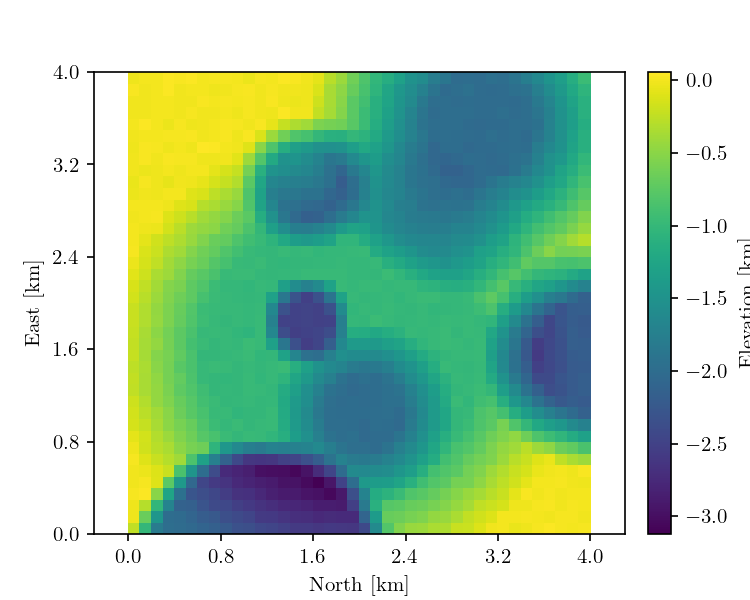

In [100]:
# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible
tot_visible = np.sum(visible_sat_num, axis=0)

# plot as a step function
t = int(N_t*2.2/24)
# plt.figure()
# plt.step(tspan/3600, tot_visible)
# plt.axvline(x=tspan[t]/3600, color='r', linestyle='--')
# plt.xlabel('Time (hrs)')
# plt.ylabel('Number of Satellites Visible')
# plt.xlim(0, tf/3600)
# plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0)
# ax.set_title(f'Time t = {tspan[t]/3600:.2f} hours')
# save the figure
plt.tight_layout()
plt.savefig('figures/dem_2D.png', dpi=600)

In [8]:
# np.rad2deg(grid_lat_long)

# A*

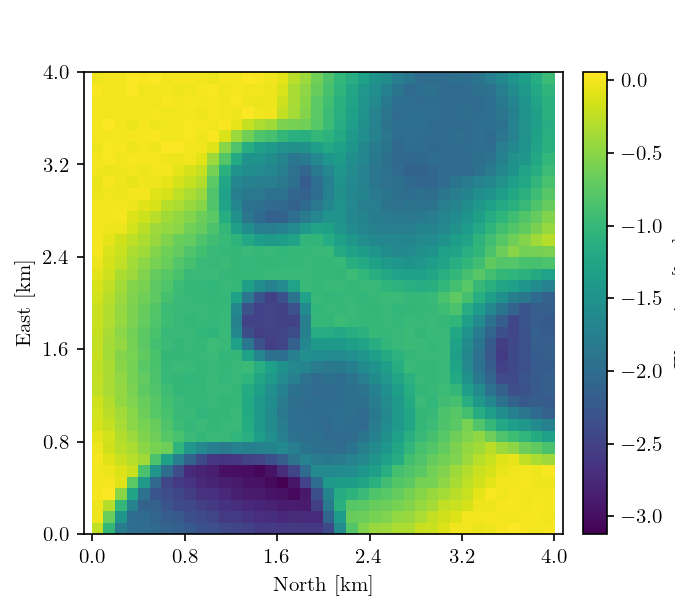

(58, 2)


In [9]:
# what we are passing in are the initial and goal inidices in the grid
x_init_idx = [7,5]
x_goal_idx = [35,30]
# get the initial and goal states in the grid
x_init = (resolution*x_init_idx[0], resolution*x_init_idx[1])
x_goal = (resolution*x_goal_idx[0], resolution*x_goal_idx[1])

# from AA274A --> needed lower bound tuple, upper bound tuple, initial state tuple, goal state tuple, occupancy as the grid, and resolution
# obstacles = [((6,7),(8,8)),((2,2),(4,3)),((2,5),(4,7)),((6,3),(8,5))]
# obstacles = [((0,7),(15,15)), ((25,22),(40,30))]
obstacles = None
weights = [1,1,1]
resolution = grid_env.res
astar = AStarPlanner((0, 0), (grid_env.N, grid_env.N), x_init, x_goal, grid_env, tspan, resolution, True, obstacles, weights)

if not astar.solve():
    print("No path found")
else:
    path_plan = astar.path
    plt.rcParams['figure.figsize'] = [4.5, 4]
    # plt.rcParams['figure.figsize'] = [3, 3]
    fig, ax = astar.plot_path()
    # astar.plot_tree()

ax.set_title(f'$w_d$ = {weights[0]}, $w_e$ = {weights[1]}, $w_p$ = {weights[2]}', fontsize=10)

waypoints = astar.get_waypoints(10)
# plot the downsampled path as scatter points
ax.plot(waypoints[:,1]/resolution, waypoints[:,0]/resolution, 'ko')
# change the fontsize of everything in the plot
plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.setp(ax.get_legend().get_texts(), fontsize=8)
plt.setp(ax.get_legend().get_title(), fontsize=8)
plt.setp(ax.title, fontsize=10)
plt.setp(ax.xaxis.label, fontsize=8)
plt.setp(ax.yaxis.label, fontsize=8)
# make the fontsize of the colorbar labels smaller
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
# save figure
#tight layout
plt.tight_layout()
fig.savefig(f'figures/path_{weights}.png', dpi=300)

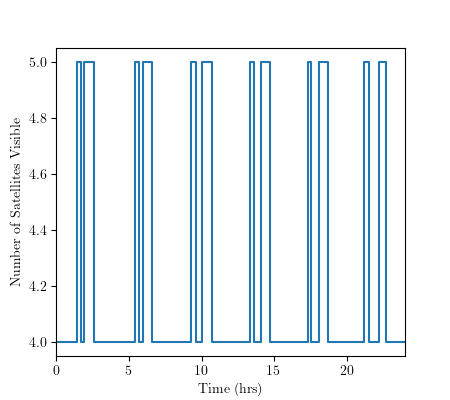

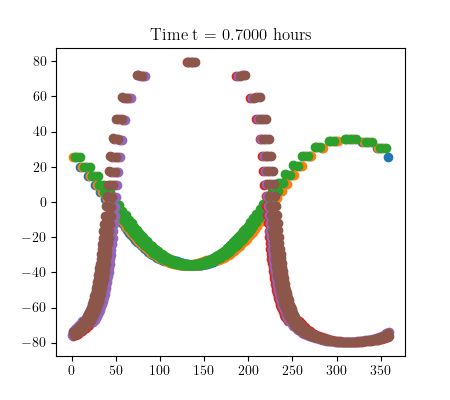

In [10]:
# rv_moon_sat_pa: Number of satellites x time vector x 6-state (x, y, z, vx, vy, vz)
ground_track = np.zeros((N_sat, N_t, 2))
ma = np.deg2rad([180, 0])
ma_4 = np.tile(ma, (1, 2))

for i_sat in range(N_sat):
    for t in range(N_t):
        # 
        pos_norm = np.linalg.norm(rv_moon_sat_pa[i_sat, t, :3])
        dec = np.arcsin(rv_moon_sat_pa[i_sat, t, 2] / pos_norm)
        if (rv_moon_sat_pa[i_sat, t, 1] / pos_norm) > 0:
            r_asc = np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        else:
            r_asc = 2 * np.pi - np.arccos(rv_moon_sat_pa[i_sat, t, 0] / pos_norm / np.cos(dec))
        dec = np.rad2deg(dec)
        r_asc = np.rad2deg(r_asc)
        ground_track[i_sat, t, :] = (dec, r_asc) # in radians

# lent = len(tspan)
# visible_sat = np.zeros((N_sat, lent))
# for i_sat in range(N_sat):
#     visible_sat[i_sat] = el_sat[i_sat] > 10
# tot_visible = np.sum(visible_sat, axis=0)

# plot as a step function
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)

plt.show()

# fig, ax = grid_env.plot_grid_elev(t=0, param_idx=2)
t = int(N_t*1.5/48)
# fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0, lat_long = True)
fig, ax = plt.figure(), plt.gca()
ax.set_title(f'Time t = {tspan[t]/3600:.4f} hours')
for i_sat in range(N_sat):
    plt.scatter(ground_track[i_sat, :, 1], ground_track[i_sat, :, 0])
    # plt.scatter(ground_track[i_sat, t, 1], ground_track[i_sat, t, 0], s=30, color = 'k')
    # print((ground_track[i_sat, N_t-20, 1], ground_track[i_sat, N_t-20, 0]))

In [11]:
# waypoints = astar.get_waypoints(10)
# waypoints_grid = waypoints/resolution
waypoints_grid = astar.get_waypoints(10)

# s0 = np.array([waypoints_grid[0, 0], waypoints_grid[0, 1], 0.0]) # initial state 
# s_goal = np.array([waypoints_grid[1, 0], waypoints_grid[1, 1], 0.0]) # desired final state

N = 5 # MPC horizon length
# P = 1e2 * np.eye(n)  # terminal state cost matrix
# Q = np.eye(n)
P = np.diag([10, 10, 1])*1e2
Q = np.diag([1, 1, 1])
R = 1e-2 * np.eye(2)  # control cost matrix

eps = 1e-3 # SCP convergence tolerance
N_scp = 10 # maximum number of SCP iterations
dt = 0.1 # time step (hrs)
T = 15 # total simulation time steps
v_bound = 1 # cells/time step
v_bound = (v_bound * resolution) / dt # km/hr
omega_bound = 3.0 # rad/hr
# omega_bound = 5.0 # deg/sec
# omega_bound *= np.pi/180 * 3600 # rad/hr

grid_coords, grid_lat_long = grid_env.grid_PA_coords(lat_user, lon_user)
grid_elev = grid_env.grid[:,:,0,2]

# s_mpc, u_mpc = run_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound)
# plot_mpc(s0, s_goal, s_mpc, u_mpc, N, T, N_scp)

(58, 2)


In [12]:
n_waypt = len(waypoints_grid)
heading = np.zeros(n_waypt)
s_mpc_list = np.zeros((T * (n_waypt - 1), N + 1, 3)) # 300x6x3
# print(s_mpc_list.shape)
u_mpc_list = np.zeros((T * (n_waypt - 1), N, 2))
true_state_total = np.zeros((T * (n_waypt-1), 3))
est_state_total = np.zeros((T * (n_waypt-1), 3))

In [107]:
# fig, ax = plt.subplots()
# fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0)

for i in range(len(waypoints_grid) - 1):
    waypt = waypoints_grid[i]
    next_waypt = waypoints_grid[i+1]
    xdist = next_waypt[0] - waypt[0]
    ydist = next_waypt[1] - waypt[1]
    heading[i] = np.arctan2(ydist, xdist)
heading[-1] = heading[-2]

# print(heading)
ekf_on = True

s0_collection = []
sgoal_collection = []

if not ekf_on:
    s0 = np.array([waypoints_grid[0,0], waypoints_grid[0,1], heading[0]])  # overall initial state
    for i in range(len(waypoints_grid) - 1):
        waypt = waypoints_grid[i]
        print(s0)
        print(np.array([waypt[0], waypt[1], heading[i]]))
        next_waypt = waypoints_grid[i+1]
        # s0 = np.array([waypt[0], waypt[1], heading[i]])
        s_goal = np.array([next_waypt[0], next_waypt[1], heading[i+1]])
        s_mpc, u_mpc, s_true = mpc.run_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound)
        
        s_mpc_list[(T * i):(T * (i+1)), :, :] = s_mpc
        u_mpc_list[(T * i):(T * (i+1)), :, :] = u_mpc
        # retrieve the very last state of the rover to set as the new initial state for the next MPC
        s_final = s_true[-1, :]

        ax.plot(s_mpc[:, 0, 1]/resolution, s_mpc[:, 0, 0]/resolution, "-o", color = 'tab:blue',label = 'MPC Path' if i == 0 else None)
        ax.scatter(s0[1]/resolution, s0[0]/resolution,color='k',zorder=3, label = 'Initial State' if i == 0 else None) 
        ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=3, label = 'Final State' if i == 0 else None) 

        # the final state of the previous iteration is the initial state of the next iteration
        s0 = np.copy(s_final)

else:
    t_true = 0
    s0 = np.array([waypoints_grid[0,0], waypoints_grid[0,1], heading[0]])  # overall initial state
    cov_final = None
    s_final_est = None
    
    for i in range(len(waypoints_grid) - 1):
        next_waypt = waypoints_grid[i+1]
        s_goal = np.array([next_waypt[0], next_waypt[1], heading[i+1]])
        s_mpc, u_mpc, t_true, true_state_array, est_state_array, cov_final = mpc_EKF.run_ekf_mpc(s0, s_goal, N, P, Q, R, T, N_scp, dt, v_bound, omega_bound, rv_moon_sat_pa, tspan, t_true, [lat_user, lon_user], grid_elev, s_final_est, cov_final)
        
        # let's collect the true states
        # don't include the last state since it's the goal state and where the rover begins at the next iteration
        true_state_total[(T * i):(T * (i+1)), :] = true_state_array[:-1,:]
        est_state_total[(T * i):(T * (i+1)), :] = est_state_array[:-1,:]
        u_mpc_list[(T * i):(T * (i+1)), :, :] = u_mpc
        s_mpc_list[(T * i):(T * (i+1)), :, :] = s_mpc
        # get where the rover actually ended up
        s_final = true_state_array[-1, :]
        s_final_est = est_state_array[-1, :]

        s0_collection.append(s0)
        sgoal_collection.append(s_goal)

        
        # ax.plot(s_mpc[:, 0, 1]/resolution, s_mpc[:, 0, 0]/resolution, "-o", color = 'tab:blue', label = 'MPC Path' if i == 0 else None, markersize=1)
        # ax.plot(true_state_array[:, 1]/resolution, true_state_array[:, 0]/resolution, "--o", color = 'tab:orange', label = 'True Path' if i == 0 else None, markersize=1)
        # ax.scatter(s0[1]/resolution, s0[0]/resolution, color='k',zorder=3, label = 'Initial State' if i == 0 else None, s = 2)
        # ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=3, label = 'Final State' if i == 0 else None, s = 2) 

        # the final state of the previous iteration is the initial state of the next iteration
        s0 = np.copy(s_final)



Initial state estimate: [ -844.73287251   289.75971222 -1492.27675016]
Initial rover estimate: [ 0.68164642  0.48518316 -0.16514868]
Intial covariance: [[0.0001 0.     0.    ]
 [0.     0.0001 0.    ]
 [0.     0.     0.0001]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.7437598705291748 seconds
Total control cost: 0.2581626552869706
Initial state estimate: [ -845.22085236   289.9677012  -1491.95443853]
Initial rover estimate: [1.30853817e+00 4.10509954e-01 8.02998119e-05]
Intial covariance: [[ 1.21799116e-05 -3.85429418e-06 -5.01954435e-07]
 [-3.85429418e-06  1.12491206e-05  7.59172485e-07]
 [-5.01954435e-07  7.59172485e-07  1.34535164e-05]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.4203190803527832 seconds
Total control cost: 0.4345949562875814
Initial state estimate: [ -845.69334066   290.12777777 -1491.65554462]
Initial rover estimate: [1.88952835 0.41422058 1.05160814]
Intial covariance: [[ 1.46957905e-05 -3.32844709e-06 -1.35740483e-06]
 [-3.32844709e-06  1.01451858e-05  9.60274360e-07]
 [-1.35740483e-06  9.60274360e-07  1.18198508e-05]]


...

Total elapsed time: 1.4143729209899902 seconds
Total control cost: 0.1893563978468766
Initial state estimate: [ -846.62327907   288.77206202 -1491.39117176]
Initial rover estimate: [2.40327941 3.4910178  0.16632028]
Intial covariance: [[ 1.24147041e-05 -4.03236881e-06 -3.40606682e-07]
 [-4.03236881e-06  1.13393196e-05  5.48609162e-07]
 [-3.40606682e-07  5.48609162e-07  1.32206301e-05]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 1.5490827560424805 seconds
Total control cost: 0.42810021663983683
Initial state estimate: [ -847.11547028   288.8815932  -1491.09051087]
Initial rover estimate: [ 2.98717796  3.59821945 -0.8484433 ]
Intial covariance: [[ 2.08959137e-05  8.52764526e-06 -2.40729504e-06]
 [ 8.52764526e-06  2.15429645e-05  1.47965971e-06]
 [-2.40729504e-06  1.47965971e-06  7.43719955e-06]]


  0%|          | 0/15 [00:00<?, ?it/s]

Total elapsed time: 2.0642499923706055 seconds
Total control cost: 0.4647489455386563


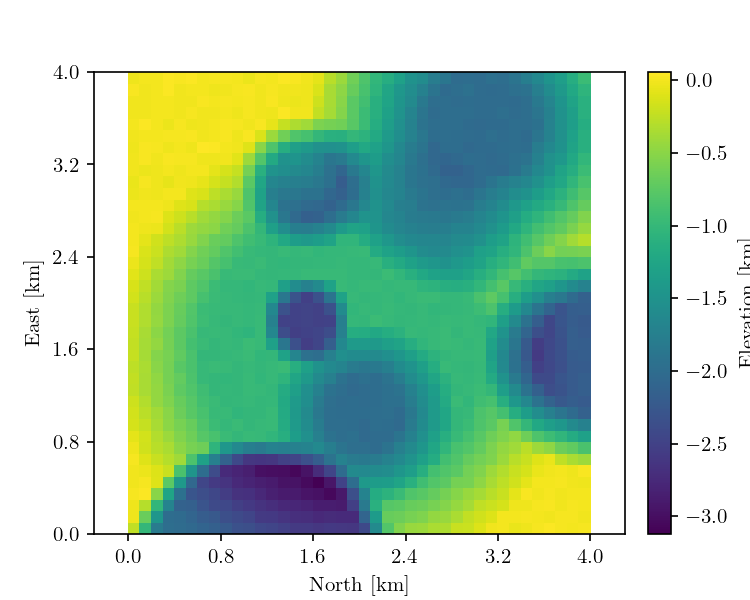

In [178]:
fig, ax = grid_env.plot_grid_elev(t=t, param_idx=0)
ax.plot(true_state_total[:, 1]/resolution, true_state_total[:, 0]/resolution, "--o", color = 'tab:blue', label = 'True Path', markersize=5)
ax.plot(est_state_total[:, 1]/resolution, est_state_total[:, 0]/resolution, "-o", color = 'tab:orange', label = 'MPC Path', markersize=5, zorder = 1)

# plot the MPC predicted trajectory
for k in range(s_mpc_list.shape[0]):
    ax.plot(s_mpc_list[k, :, 1]/resolution, s_mpc_list[k, :, 0]/resolution, "-*", zorder = 1, color = 'gray', markersize=5, label = 'MPC Horizon' if k == 0 else None)
    

for s_idx in range(len(s0_collection)):
    s0 = s0_collection[s_idx]
    s_goal = sgoal_collection[s_idx]
    ax.scatter(s0[1]/resolution, s0[0]/resolution, color='k',zorder=3, label = 'Starting State' if s_idx == 1 else None, s = 150, marker = 'x')
    ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=4, label = 'Goal Waypoint' if s_idx == 1 else None, s = 150, marker = 'x')

# ax.scatter(s0[1]/resolution, s0[0]/resolution, color='k',zorder=3, label = 'Initial State', s = 2)
# ax.scatter(s_goal[1]/resolution, s_goal[0]/resolution,color='r',zorder=3, label = 'Final State', s = 2) 
# ax.axis("equal")
# legend = ax.legend(fontsize=10, loc = 'upper right')
# legend.get_frame().set_alpha(None)
ax_sub = plt.gca()

# # zoom into the region of interest
ax_sub.set_xlim([3, 7])
ax_sub.set_ylim([6, 14])
# take out axis labels
ax_sub.set_xlabel("")
ax_sub.set_ylabel("")

#remove colorbar
cbar = ax.collections[0].colorbar
cbar.remove()

# make axis labels bigger
# plt.setp(ax_sub.get_xticklabels(), fontsize=8)
# plt.setp(ax_sub.get_yticklabels(), fontsize=8)

# save the figure
plt.tight_layout()
plt.savefig('figures/ekf_mpc_DEM.png', dpi=800)
# plt.gca().invert_yaxis()

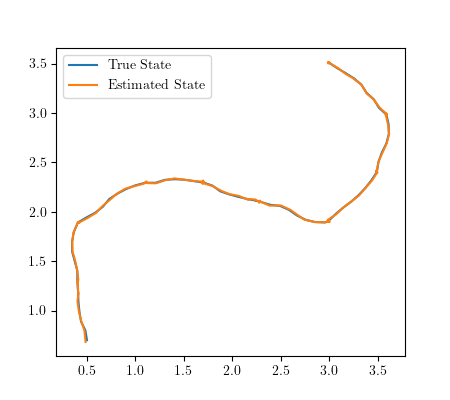

In [52]:
fig = plt.figure()
plt.plot(true_state_total[:, 1], true_state_total[:, 0], label='True State') 
plt.plot(est_state_total[:, 1], est_state_total[:, 0], label='Estimated State') 
plt.legend()

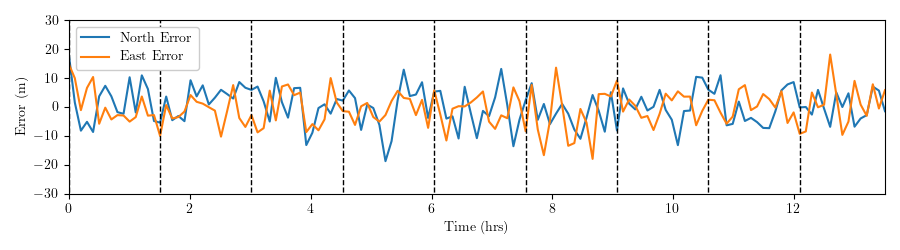

In [53]:
t_vec = np.linspace(0, t_true/3600, len(true_state_total[:, 0]))

fig = plt.figure(figsize=(9, 2.5))
plt.plot(t_vec, (true_state_total[:, 0] - est_state_total[:, 0])*1000, label='North Error')
plt.plot(t_vec, (true_state_total[:, 1] - est_state_total[:, 1])*1000, label='East Error')
plt.vlines(t_vec[::T], -50, 50, color='k', linestyle='--', linewidth=1)   
plt.xlabel('Time (hrs)')
plt.ylabel('Error (m)')
plt.ylim(-30, 30)
plt.xlim(0, t_vec[-1])
# plt.grid()
#make legend not transparent
legend = plt.legend()
legend.get_frame().set_alpha(None)
plt.tight_layout()
plt.savefig('figures/ekf_error.png', dpi=300)

[0.7 1.3 1.9 2.3 2.3 2.1 1.9 2.4 3.  3.5]


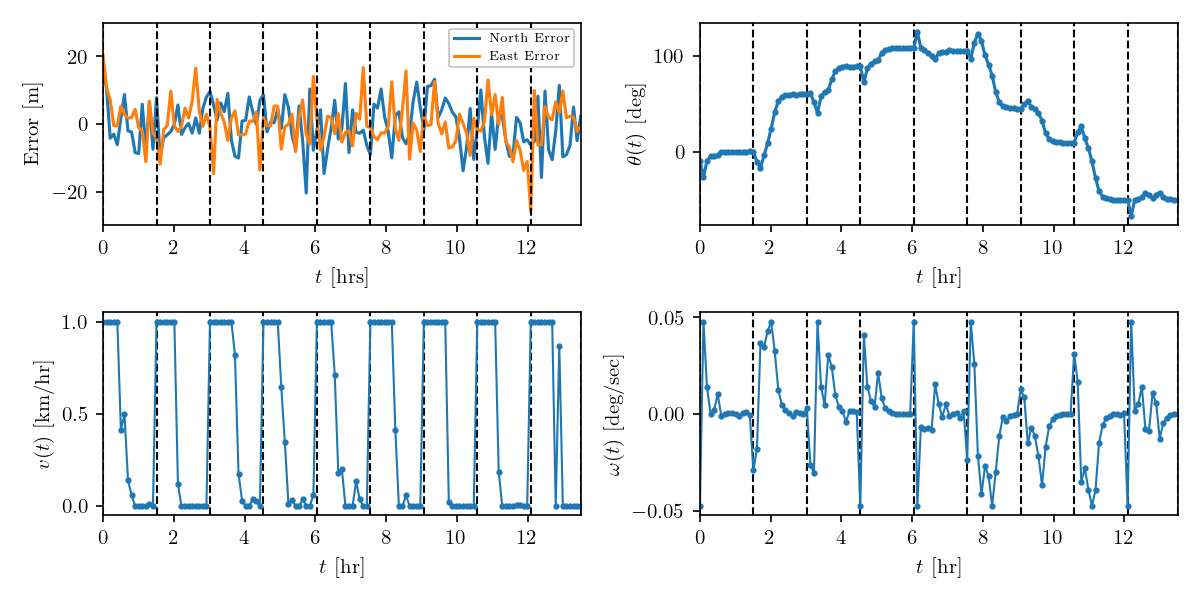

In [69]:
first_waypt, last_waypt = waypoints_grid[0], waypoints_grid[-1]
print(waypoints_grid[:, 0])
# s0 = np.array([first_waypt[0], first_waypt[1], heading[0]])
# s_goal = np.array([last_waypt[0], last_waypt[1], heading[-1]])
s0 = np.array([waypoints_grid[:, 0], waypoints_grid[:, 1], heading])
s_goal = s0
# s_goal = np.array([last_waypt[0], last_waypt[1], heading[-1]])
fig, ax_mpc = mpc_EKF.plot_mpc(s0, s_goal, s_mpc_list, u_mpc_list, N, T, N_scp, n_waypt, dt)
# ax_mpc[0,0] = ax_sub



# fig = plt.figure(figsize=(9, 2.5))
ax_mpc[0,0].plot(t_vec, (true_state_total[:, 0] - est_state_total[:, 0])*1000, label='North Error')
ax_mpc[0,0].plot(t_vec, (true_state_total[:, 1] - est_state_total[:, 1])*1000, label='East Error')
ax_mpc[0,0].vlines(t_vec[::T], -50, 50, color='k', linestyle='--', linewidth=1)   
ax_mpc[0,0].set_xlabel('$t$ [hrs]')
ax_mpc[0,0].set_ylabel('Error [m]')
ax_mpc[0,0].set_ylim(-30, 30)
ax_mpc[0,0].set_xlim(0, t_vec[-1])

# plt.grid()
#make legend not transparent
legend = ax_mpc[0, 0].legend(fontsize=6, loc = 'upper right')
legend.get_frame().set_alpha(None)
plt.tight_layout()
plt.savefig('figures/mpc_states_ekf.png', dpi=500) 
# plt.show()

In [35]:
np.sqrt((1.3-0.7)**2 + (0.4-0.5)**2)

0.608276253029822

# EKF TIME

In [36]:
rv_moon_sat_pa.shape

(6, 241, 6)

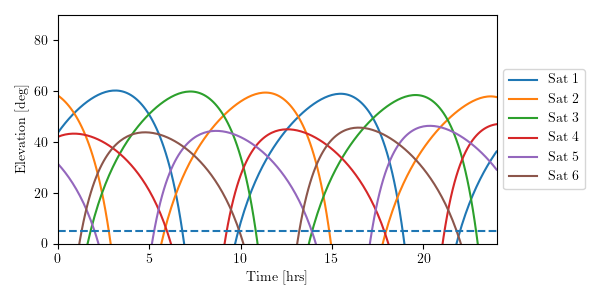

In [80]:
fig = plt.figure(figsize=(6, 3))
for i_sat in range(N_sat):
    plt.plot(tspan/3600, el_sat[i_sat], label='Sat ' + str(i_sat+1))
plt.xlabel('Time [hrs]')
plt.ylabel('Elevation [deg]')
plt.axhline(5, linestyle='--')
plt.tight_layout()
# plt.legend(loc='upper right', box_to_anchor=(1.3, 1))
# make legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0, 90)
plt.xlim(0, tf/3600)
plt.tight_layout()
plt.savefig('figures/elevation.png', dpi=500)

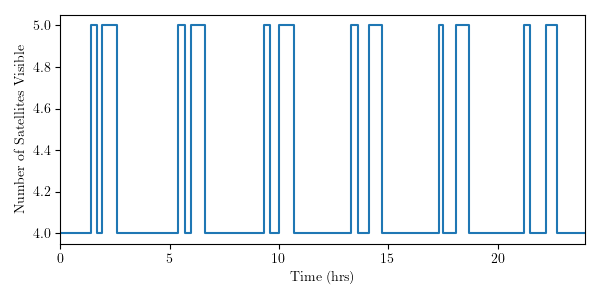

In [82]:
fig = plt.figure(figsize=(6, 3))

plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)
plt.tight_layout()
plt.savefig('figures/nsat_vis.png', dpi=500)